## 9.3 正则化 - 批量归一化（Batch Normalization）

#### 1. 为什么需要 Batch Normalization
在训练深度神经网络时，会遇到一个经典问题：
* 随着层数加深
* 数据分布不断变化

这就是：
* 内部协变量偏移（Internal Covariate Shift）

##### 1.1 什么是内部协变量偏移
假设：

`第1层输出 → 第2层输入`

但在训练过程中：
* 第1层参数不断更新

导致：
* 第2层输入分布不断变化

例如：
* 第一轮：均值 = 0
* 第十轮：均值 = 5

这会导致：
* 后面的层很难稳定学习

##### 1.2 带来的问题
* 训练不稳定
* 收敛速度慢
* 对学习率敏感

##### 1.3 BatchNorm 的目标
BatchNorm 的核心目标是：

`让每一层的输入分布稳定`

#### 2. Batch Normalization 的核心思想
对每一层的输入进行标准化（归一化）

##### 2.1 标准化操作
对于一个 batch 的数据：

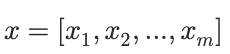

1. 计算均值

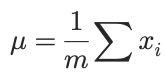

2. 计算方差

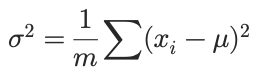

3. 进行归一化

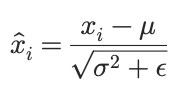

##### 2.2 为什么还要引入 γ 和 β
如果只做标准化：
* 所有数据都会变成均值0、方差1

但这可能：
* 限制模型表达能力

所以引入两个可学习参数：

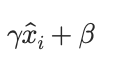

##### 2.3 这一步的意义
模型可以自己决定：
* 是否需要标准化
* 需要多少标准化

#### 3. BatchNorm 的完整流程
可以总结为：
```
输入 x
↓
计算均值 μ
↓
计算方差 σ²
↓
标准化
↓
线性变换（γ, β）
↓
输出
```

##### 示例：BatchNorm 的完整计算过程（带数字）
假设我们有一个 batch（batch size = 4），某一层的输出为：

`x = [2, 4, 6, 8]`

1. 计算均值

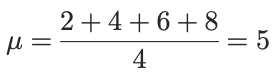

2. 计算方差

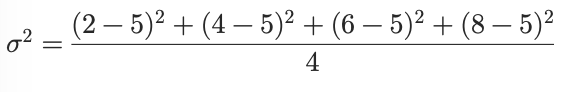
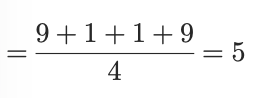

3. 标准化（Normalization）

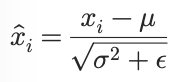

忽略 ε（简化理解）：

`sqrt(5) ≈ 2.24`

计算：
```
(2 - 5) / 2.24 ≈ -1.34
(4 - 5) / 2.24 ≈ -0.45
(6 - 5) / 2.24 ≈  0.45
(8 - 5) / 2.24 ≈  1.34
```

得到：

`x_hat ≈ [-1.34, -0.45, 0.45, 1.34]`

👉 此时：
* 均值 ≈ 0
* 方差 ≈ 1

4. 线性变换（γ, β）

假设：
```
γ = 2
β = 1
```

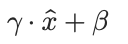

计算：

`[-1.68, 0.10, 1.90, 3.68]`

#### 4. BatchNorm 为什么也算正则化
虽然 BatchNorm 的主要目的是：
* 稳定训练

但它也具有：
* 正则化效果

**1️⃣ 原因：使用 batch 统计量**

每个 batch 的：
* 均值和方差不同

导致：
* 每次训练都有“噪声”

**2️⃣ 类似 Dropout 的效果**
* 引入随机性
* 减少过拟合

**3️⃣ 实际效果**

很多时候：
* 使用 BatchNorm 后
* 甚至可以减少 Dropout

#### 5. 训练阶段 vs 测试阶段
BatchNorm 和 Dropout 一样，也有两种模式：

**1️⃣ 训练阶段**

使用当前 batch 的均值和方差

**2️⃣ 测试阶段**

使用训练过程中累计的均值和方差

（running mean / running var）

#### 6. BatchNorm vs Dropout
```
方法	作用方式
Dropout	随机关闭神经元
BatchNorm	稳定数据分布
```

🔥 核心区别
* Dropout → 强正则化
* BatchNorm → 稳定训练 + 轻正则化

##### 哪个方法更广泛使用
从现代深度学习的实际应用来看：

`BatchNorm 通常比 Dropout 更广泛使用`

**（1）BatchNorm 不仅能正则化，还能稳定训练**

BatchNorm 的作用不只是：
* 轻微正则化

更重要的是：
* 稳定数据分布
* 加快收敛
* 减轻梯度问题
* 所以它的价值更全面。

**（2）BatchNorm 在很多网络中几乎是默认组件**

例如：
* CNN
* ResNet
* 很多图像任务模型

BatchNorm 经常是：标准配置

**（3）Dropout 在现代网络中使用得更有选择性**

Dropout 当然仍然很重要，但相比 BatchNorm：

使用场景更依赖具体任务

例如：
* 在 MLP / 全连接层 中很常见
* 在一些 小数据集、明显过拟合 的场景中很有帮助
* 但在很多使用 BatchNorm 的 CNN 中，Dropout 可能会减少使用，甚至不用
